# Import libraries

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

# Import des librairies standards
import pandas as pd
import numpy as np
# Scikit-learn : Preprocessing & Modèles
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,	GradientBoostingClassifier, StackingClassifier

# Visualisation (Plotly)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
import matplotlib.pyplot as plt
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

In [2]:
from src.build_dataset    import build_ml_dataset
from src.preprocessing_ml import prepare_features

df = build_ml_dataset()

# ✅ Vérification obligatoire avant de continuer
print(f"\nShape df : {df.shape}")
print(f"Gravite unique : {df['gravite'].unique()}")
print(f"Gravite_binaire : {df['gravite_binaire'].value_counts().to_dict()}")

🔍 Query : SELECT * FROM public."ml_dataset_final" 
✅ ml_dataset_final : 506,886 lignes × 64 colonnes
📊 506,886 lignes × 64 colonnes
Mortels : 13,599 / 506,886

Shape df : (506886, 64)
Gravite unique : [ 1.  4.  3.  2. nan]
Gravite_binaire : {0: 493287, 1: 13599}


# Read file with labels

In [3]:
print('Set with labels (our train+test) :', df.shape)

Set with labels (our train+test) : (506886, 64)


In [4]:
df.head()

,Num_Acc,id_usager,id_vehicule,gravite,graviter_blessure_label,gravite_binaire,sexe,sexe_label,annee_naissance,age_victime_jour,...,categorie_route_label,regime_circulation,nb_voies,profil_route,etat_surface,etat_surface_label,infrastructure,infrastucture_label,situation_accident,vitesse_max_autorisee
0,202400015832,203 951 291,155 753 897,1.0,Indemne,0,2.0,Femme,1961.0,63.0,...,None,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN
1,202400015833,203 951 286,155 753 893,1.0,Indemne,0,1.0,Homme,1962.0,62.0,...,None,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN
2,202400015833,203 951 288,155 753 895,4.0,Blessé léger,0,2.0,Femme,1987.0,37.0,...,None,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN
3,202400015833,203 951 290,155 753 895,1.0,Indemne,0,1.0,Homme,1993.0,31.0,...,None,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN
4,202400015833,203 951 292,155 753 895,1.0,Indemne,0,1.0,Homme,1993.0,31.0,...,None,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN


# Explore dataset

In [5]:
df.describe()

,Num_Acc,gravite,gravite_binaire,sexe,annee_naissance,age_victime_jour,categorie_usager,motif_trajet,equipement_secu1,equipement_secu2,...,type_collision,vacances_scolaires_flag,categorie_route,regime_circulation,nb_voies,profil_route,etat_surface,infrastructure,situation_accident,vitesse_max_autorisee
count,5.068860e+05,506467.000000,506886.000000,496254.000000,476075.000000,476075.000000,506886.000000,495617.000000,497021.000000,282965.000000,...,506679.000000,506886.000000,1156.000000,786.000000,1059.000000,1156.000000,1156.000000,1106.000000,1156.000000,1156.000000
mean,2.022487e+11,2.520685,0.026829,1.317069,1982.633369,39.849112,1.329761,3.228085,1.941910,2.382206,...,3.754924,0.321550,4.191176,1.846056,1.626062,1.168685,1.306228,2.631103,3.624567,19.060554
std,1.119707e+08,1.375789,0.161582,0.465335,18.254760,18.253250,0.609076,2.731623,2.307171,3.281004,...,1.865127,0.467072,1.465550,0.573705,1.269804,0.428535,1.117199,3.627882,2.666623,16.005079
min,2.021000e+11,1.000000,0.000000,1.000000,1912.000000,11.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,2.021001e+11,1.000000,0.000000,1.000000,1970.000000,24.000000,1.000000,0.000000,1.000000,0.000000,...,2.000000,0.000000,3.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,5.000000
50%,2.022001e+11,3.000000,0.000000,1.000000,1986.000000,36.000000,1.000000,4.000000,1.000000,0.000000,...,3.000000,0.000000,4.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,15.000000
75%,2.023001e+11,4.000000,0.000000,2.000000,1998.000000,53.000000,2.000000,5.000000,2.000000,6.000000,...,6.000000,1.000000,4.000000,2.000000,2.000000,1.000000,1.000000,6.000000,5.000000,25.000000
max,2.024001e+11,4.000000,1.000000,2.000000,2010.000000,110.000000,3.000000,9.000000,9.000000,9.000000,...,7.000000,1.000000,9.000000,4.000000,7.000000,4.000000,9.000000,9.000000,8.000000,95.000000


### Preparation of data

In [6]:
X, y = prepare_features(df)

# ✅ STOP si moins de 1000 lignes — quelque chose cloche
assert len(y) > 1000, f"❌ Dataset trop petit : {len(y)} lignes — vérifier build_ml_dataset()"
assert y.sum() > 100,  f"❌ Pas assez de mortels : {y.sum()} — vérifier gravite_binaire"

print(f"\n✅ X : {X.shape}")
print(f"✅ Mortels   : {y.sum():,}")
print(f"✅ Non mortels: {(y==0).sum():,}")

✅ X : (506886, 22)
✅ Mortels : 13,599 / 506,886 (2.68%)

✅ X : (506886, 22)
✅ Mortels   : 13,599
✅ Non mortels: 493,287


In [7]:
target_variable = 'converted'
X = df.drop(columns="converted")
Y = df.loc[:, target_variable]

print('Explanatory variables : ', X.columns)
print()

KeyError: "['converted'] not found in axis"

In [9]:
# Divide dataset Train set & Test set 
print("Dividing into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ← garantit des mortels dans le test
)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [10]:
# Automatically detect names of numeric/categorical columns
numeric_features = []
categorical_features = []
for column,type in X.dtypes.items():
    if ('float' in str(type)) or ('int' in str(type)) :
        numeric_features.append(column)
    else :
        categorical_features.append(column)

print('\nFound numeric features ', numeric_features)
print('Found categorical features ', categorical_features)


Found numeric features  ['categorie_usager_label', 'motif_trajet_label', 'equipement_secu_1_label', 'equipement_secu_2_label', 'equipement_secu_3_label', 'tranche_age', 'sexe', 'categorie_vehicule_label', 'motorisation_label', 'obstacle_fixe_label', 'obstacle_mobile_label', 'luminosite_label', 'agglomeration_label', 'intersection_label', 'meteo_label', 'type_collision_label', 'tranche_horaire_label', 'categorie_route_label', 'etat_surface_label', 'infrastucture_label', 'vacances_scolaires_flag', 'vitesse_max_autorisee']
Found categorical features  []


### Training pipeline

In [11]:
# Put here all the preprocessings
print("Encoding categorical features and standardizing numerical features...")

# Create pipeline for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # missing values will be replaced by columns' mean
    ('scaler', StandardScaler())
])

# Create pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder(drop='first')) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTransformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

message = "Preprocessing X_train : ✅\n"
print(f"\033[1m{message}\033[0m")
X_train = preprocessor.fit_transform(X_train)
print(X_train[0:5,:]) # X_train is now a numpy array

message = "\nPreprocessing X_test : ✅\n"
print(f"\033[1m{message}\033[0m")
X_test = preprocessor.transform(X_test)
print(X_test[0:5,:]) # X_test is now a numpy array

Encoding categorical features and standardizing numerical features...
Preprocessing X_train : ✅

[[-0.54195339  0.09324153  2.68452293  0.92667103  0.18281256  1.74873251
   3.17390015 -2.08980118 -1.75002865  0.32572408  1.32464227  0.59480402
  -0.79680735  0.51507855 -0.36712333 -1.10856599  0.89893132  0.03621911
  -0.04339042  0.02762121 -0.68773034 -0.03649851]
 [ 2.74184304  0.69104998 -1.51169172  0.92667103  0.18281256  1.01600486
   1.24817376  0.54431112 -2.67286691  0.32572408  1.32464227 -1.37561053
  -0.79680735  1.37088293 -0.36712333 -1.10856599  0.89893132  0.03621911
  -0.04339042  0.02762121 -0.68773034 -0.03649851]
 [ 1.09994483  0.69104998 -0.1129535   0.92667103  0.18281256 -1.18217807
   1.24817376  0.54431112  0.09564785 -3.032486   -1.83777263 -1.37561053
  -0.79680735 -0.34072583 -0.36712333 -1.10856599 -2.0050424   0.03621911
  -0.04339042  0.02762121 -0.68773034 -0.03649851]
 [-0.54195339  0.69104998 -0.57919957 -0.0392097   0.18281256  0.28327722
  -0.67755

In [13]:
message = "\nTrain model : ✅\n"
print(f"\033[1m{message}\033[0m")
classifier = LogisticRegression()
classifier.fit(X_train, Y_train)


Train model : ✅



NameError: name 'Y_train' is not defined

In [ ]:
# Predictions on training set
message = "\nPredictions on training set : ✅\n"
print(f"\033[1m{message}\033[0m")
Y_train_pred = classifier.predict(X_train)
print(Y_train_pred)

message = "\nPredictions on test set : ✅\n"
print(f"\033[1m{message}\033[0m")
Y_test_pred = classifier.predict(X_test)
print(Y_test_pred)


Predictions on training set : ✅

[0 0 0 ... 1 0 0]

Predictions on test set : ✅

[0 0 0 ... 0 0 0]


### Performance assessment

In [ ]:
# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

new_rows = [
    {'model': 'multi_logistic_reg', 'f1_score': f1_score(Y_train, Y_train_pred), 'set': 'train'},
    {'model': 'multi_logistic_reg', 'f1_score': f1_score(Y_test, Y_test_pred), 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df["label"]=scores_df.model+"_"+scores_df.set
scores_df

f1-score on train set :  0.7650638667825854
f1-score on test set :  0.7493827160493827


,model,f1_score,set,label
0,simple_logistic_reg,0.695799,train,simple_logistic_reg_train
1,simple_logistic_reg,0.689320,test,simple_logistic_reg_test
2,multi_logistic_reg,0.765064,train,multi_logistic_reg_train
3,multi_logistic_reg,0.749383,test,multi_logistic_reg_test


Le f1-score est bon (~>0.75), les 1 sont globalement bien prédits. C'est mieux que la Régression logistique simple avec un f1-score de 0.7

In [ ]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set : 
[[246887    973]
 [  2540   5720]]

Confusion matrix on test set : 
[[27445    95]
 [  311   607]]



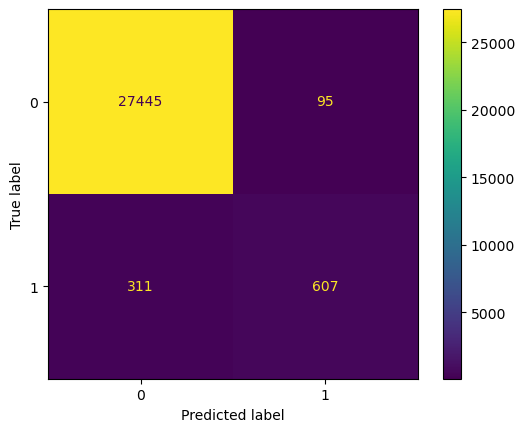

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(Y_test, Y_test_pred)).plot()

Le modèle se trompe 1.54% dès fois avec un faux négatif et un faux positif. C'est moins que la Régression linéaire simple. Essayons d'autres modèles pour voir si on peut progresser le f1-score

## Decision Tree

In [ ]:
params = {
    "max_depth": np.arange(1,10),
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 4, 8],
}

gridsearch_gini = GridSearchCV(DecisionTreeClassifier(criterion="gini"), param_grid=params, cv=3) 
gridsearch_gini.fit(X_train, Y_train)

print("Best hyperparameters : ", gridsearch_gini.best_params_)

gridsearch_entropy = GridSearchCV(DecisionTreeClassifier(criterion="entropy"), param_grid=params, cv=3) 
gridsearch_entropy.fit(X_train, Y_train)

print("Best hyperparameters : ", gridsearch_entropy.best_params_)

#F1_score
print("/nGini f1_score :")
print(f1_score(Y_train,gridsearch_gini.predict(X_train)))
print(f1_score(Y_test,gridsearch_gini.predict(X_test)))

print("/nEntropy f1_score :")
print(f1_score(Y_train,gridsearch_entropy.predict(X_train)))
print(f1_score(Y_test,gridsearch_entropy.predict(X_test)))


Best hyperparameters :  {'max_depth': np.int64(9), 'min_samples_leaf': 5, 'min_samples_split': 2}
Best hyperparameters :  {'max_depth': np.int64(8), 'min_samples_leaf': 2, 'min_samples_split': 2}
/nGini f1_score :
0.7721889554224883
0.7388379204892966
/nEntropy f1_score :
0.7562134999320929
0.7298814722395508


## Random Forest

Combinaisons de params = 5 × 3 × 3 × 6 = 270 combinaisons  
CV folds               = 3  
─────────────────────────────────────────  
Total de fits          = 270 × 3 = 810 fits  


Estimation par modèle :  
10k lignes~~14 min  
50k lignes~40 min  
284k lignes~2h - 4h ⚠️  

In [ ]:
params = {
    'max_depth': [4, 8, 10],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 4, 8],
    'n_estimators': [20, 60, 100, 120]
}

random_forest = RandomForestClassifier()

# gridsearch = GridSearchCV(
#     random_forest,
#     param_grid = params,
#     cv=3,
#     verbose=1,
#     n_jobs=-1,
#     scoring='f1'  
# )

gridsearch = RandomizedSearchCV(
    random_forest,
    param_distributions = params,
    n_iter=30,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='f1',
    random_state=42
)

gridsearch.fit(X_train, Y_train)

# Predictions on training set
message = "\nPredictions on training set : ✅\n"
print(f"\033[1m{message}\033[0m")
Y_train_pred = gridsearch.predict(X_train)
print(Y_train_pred)

message = "\nPredictions on test set : ✅\n"
print(f"\033[1m{message}\033[0m")
Y_test_pred = gridsearch.predict(X_test)
print(Y_test_pred)

print("/nBest hyperparameters : ", gridsearch.best_params_)

print("/nF1 on training set : ", f1_score(Y_train, Y_train_pred))
print("F1 on test set : ", f1_score(Y_test, Y_test_pred))

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Predictions on training set : ✅

[0 0 0 ... 1 0 0]

Predictions on test set : ✅

[0 0 0 ... 0 0 0]
/nBest hyperparameters :  {'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_depth': 10}
/nF1 on training set :  0.7767588191980722
F1 on test set :  0.7419753086419754


In [ ]:
new_rows = [
    {'model': 'random_forest', 'f1_score': f1_score(Y_train, Y_train_pred), 'set': 'train'},
    {'model': 'random_forest', 'f1_score': f1_score(Y_test, Y_test_pred), 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df["label"]=scores_df.model+"_"+scores_df.set
scores_df

,model,f1_score,set,label
0,simple_logistic_reg,0.695799,train,simple_logistic_reg_train
1,simple_logistic_reg,0.689320,test,simple_logistic_reg_test
2,multi_logistic_reg,0.765064,train,multi_logistic_reg_train
3,multi_logistic_reg,0.749383,test,multi_logistic_reg_test
4,random_forest,0.776759,train,random_forest_train
5,random_forest,0.741975,test,random_forest_test


## Bagging

In [ ]:
decision_tree = DecisionTreeClassifier(max_depth = 10, min_samples_leaf = 2, min_samples_split = 5)
bagging = BaggingClassifier(estimator=decision_tree, n_estimators = 100)
bagging.fit(X_train, Y_train)

print("F1 on training set : ", f1_score(Y_train, Y_train_pred))
print("F1 on test set : ", f1_score(Y_test, Y_test_pred))

# Predictions on training set
message = "\nPredictions on training set : ✅\n"
print(f"\033[1m{message}\033[0m")
Y_train_pred = bagging.predict(X_train)
print(Y_train_pred)

message = "\nPredictions on test set : ✅\n"
print(f"\033[1m{message}\033[0m")
Y_test_pred = bagging.predict(X_test)
print(Y_test_pred)

new_rows = [
    {'model': 'bagging', 'f1_score': f1_score(Y_train, Y_train_pred), 'set': 'train'},
    {'model': 'bagging', 'f1_score': f1_score(Y_test, Y_test_pred), 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df["label"]=scores_df.model+"_"+scores_df.set
scores_df

F1 on training set :  0.7767588191980722
F1 on test set :  0.7419753086419754

Predictions on training set : ✅

[0 0 1 ... 1 0 0]

Predictions on test set : ✅

[0 0 0 ... 0 0 0]


,model,f1_score,set,label
0,simple_logistic_reg,0.695799,train,simple_logistic_reg_train
1,simple_logistic_reg,0.689320,test,simple_logistic_reg_test
2,multi_logistic_reg,0.765064,train,multi_logistic_reg_train
3,multi_logistic_reg,0.749383,test,multi_logistic_reg_test
4,random_forest,0.776759,train,random_forest_train
5,random_forest,0.741975,test,random_forest_test
6,bagging,0.783538,train,bagging_train
7,bagging,0.744186,test,bagging_test


## XGBoosting

In [ ]:
XGBoost = XGBClassifier()

params = {
    'n_estimators':     [100, 200, 300],        # nombre d'arbres
    'max_depth':        [3, 4, 5, 6],           # profondeur max
    'learning_rate':    [0.01, 0.05, 0.1, 0.3], # vitesse d'apprentissage
    'subsample':        [0.7, 0.8, 1.0],         # % de lignes par arbre
}

# gridsearch = GridSearchCV(
#     XGBoost,
#     param_distributions=params,
#     cv=3,
#     verbose=1,
#     n_jobs=-1,
#     scoring='f1'  
# )

gridsearch = RandomizedSearchCV(
    XGBoost,
    param_distributions = params,
    n_iter=30,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='f1',
    random_state=42  
)

gridsearch.fit(X_train, Y_train)

print("F1 on training set : ", f1_score(Y_train, Y_train_pred))
print("F1 on test set : ", f1_score(Y_test, Y_test_pred))

# Predictions on training set
message = "\nPredictions on training set : ✅\n"
print(f"\033[1m{message}\033[0m")
Y_train_pred = gridsearch.predict(X_train)
print(Y_train_pred)

message = "\nPredictions on test set : ✅\n"
print(f"\033[1m{message}\033[0m")
Y_test_pred = gridsearch.predict(X_test)
print(Y_test_pred)

new_rows = [
    {'model': 'XGB', 'f1_score': f1_score(Y_train, Y_train_pred), 'set': 'train'},
    {'model': 'XGB', 'f1_score': f1_score(Y_test, Y_test_pred), 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df["label"]=scores_df.model+"_"+scores_df.set
scores_df

Fitting 3 folds for each of 30 candidates, totalling 90 fits
F1 on training set :  0.7835380019913707
F1 on test set :  0.7441860465116279

Predictions on training set : ✅

[0 0 0 ... 1 0 0]

Predictions on test set : ✅

[0 0 0 ... 0 0 0]


,model,f1_score,set,label
0,simple_logistic_reg,0.695799,train,simple_logistic_reg_train
1,simple_logistic_reg,0.689320,test,simple_logistic_reg_test
2,multi_logistic_reg,0.765064,train,multi_logistic_reg_train
3,multi_logistic_reg,0.749383,test,multi_logistic_reg_test
4,random_forest,0.776759,train,random_forest_train
5,random_forest,0.741975,test,random_forest_test
6,bagging,0.783538,train,bagging_train
7,bagging,0.744186,test,bagging_test
8,XGB,0.770507,train,XGB_train
9,XGB,0.752584,test,XGB_test


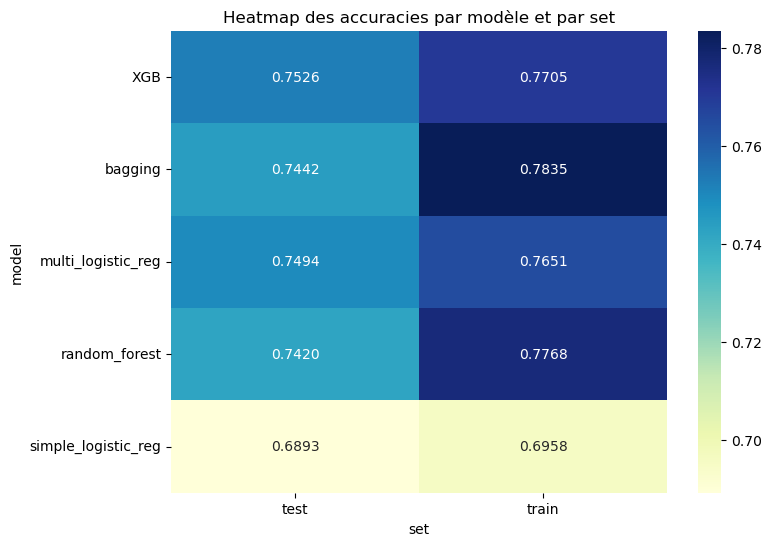

In [ ]:
# Création d'une heatmap
df_heatmap = scores_df.pivot(index="model", columns="set", values="f1_score")
plt.figure(figsize=(8, 6))
sns.heatmap(df_heatmap, annot=True, cmap="YlGnBu", fmt=".4f")
plt.title("Heatmap des accuracies par modèle et par set")
plt.show()

Best on training sets, the best model seems to be  Bagging> RF > XGB but there is more overfitting on the first two than XGB, since the XGB performance on test set is higher

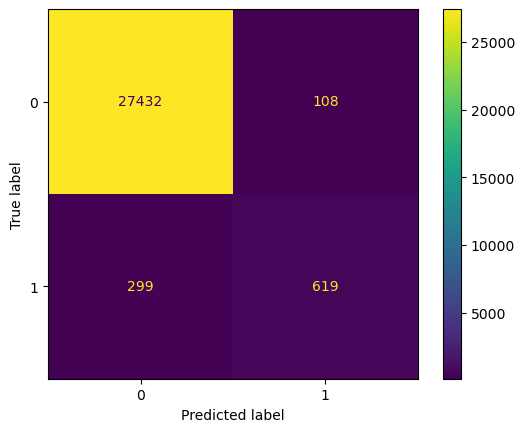

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(Y_test, Y_test_pred)).plot()

# Train best classifier on all data and use it to make predictions on X_without_labels
**Before making predictions on the file conversion_data_test.csv, let's train our model on ALL the data that was in conversion_data_train.csv. Sometimes, this allows to make tiny improvements in the score because we're using more examples to train the model.**

In [ ]:
# Concatenate our train and test set to train your best classifier on all data with labels
X = np.append(X_train,X_test,axis=0)
Y = np.append(Y_train,Y_test)

gridsearch.fit(X,Y)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.7, 0.8, ...]}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
# 1. Charger les données
data_without_labels = pd.read_csv('conversion_data_test.csv')

# 2. Transformer avec le preprocessor DÉJÀ fit
X_without_labels_transformed = preprocessor.transform(data_without_labels)

# 3. Prédire avec ton modèle
y_pred = gridsearch.predict(X_without_labels_transformed)

# (optionnel) proba
y_pred = gridsearch.predict(X_without_labels_transformed)

# 4. EXPORT
submission = pd.DataFrame({'converted': y_pred})
submission.to_csv('conversion_data_test_predictions_FINAL.csv', index=False)
print("Terminé ! ✅")

Terminé ! ✅


## Analyzing the coefficients and interpreting the result
**In this template, we just trained a model with only one feature (total_pages_visited), so there's no analysis to be done about the feature importance 🤔**

**Once you've included more features in your model, please take some time to analyze the model's parameters and try to find some lever for action to improve the newsletter's conversion rate 😎😎**

In [ ]:
# # ✅ FEATURE ENGINEERING
# df['high_pages'] = (df['total_pages_visited'] > df['total_pages_visited'].median()).astype(int)
# df['is_usa'] = (df['country'] == 'US').astype(int)  # Feature importante ?
# df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 100], labels=['young', 'mid', 'senior']).astype(str)
